Output()

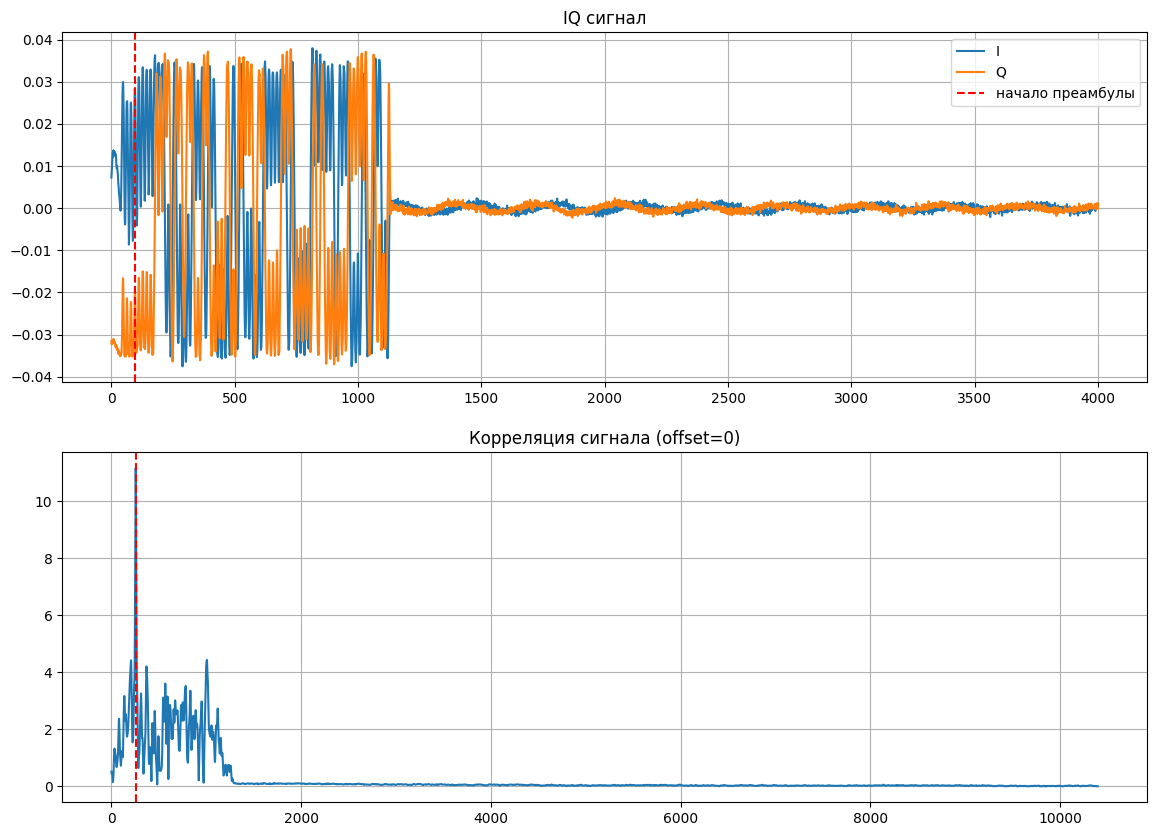

In [3]:
import ipywidgets as widgets
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent   
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import display, clear_output
from modem.blocks import (
    BLE_GFSK_Modulator,
    BLE_GFSK_Demodulator,
    PreambleSearcher,
    DataExtractor,
    Dewhitener,
    synthesize_ble_packet
)

# ============================================================
# Параметры BLE
# ============================================================
FS = 8e6
SPS = 8
DEV = 250e3

# Преамбула (40 бит)
sync_byte = 0xAA
access_addr = 0x8E89BED6
sync_bits = np.unpackbits(np.array([sync_byte], dtype=np.uint8), bitorder="little")
addr_bytes = access_addr.to_bytes(4, "little")
addr_bits = np.unpackbits(np.frombuffer(addr_bytes, dtype=np.uint8), bitorder="little")
PREAMBLE_BITS = np.concatenate([sync_bits, addr_bits])


# ============================================================
# Функция анализа файла
# ============================================================
def analyze_ble_file(filename, offset, whitening_channel):
    fs = 8e6
    sps = 8
    dev = 250e3

    # Преамбула (40 бит)
    sync_byte = 0xAA
    access_addr = 0x8E89BED6
    sync_bits = np.unpackbits(np.array([sync_byte], dtype=np.uint8), bitorder="little")
    addr_bytes = access_addr.to_bytes(4, "little")
    addr_bits = np.unpackbits(np.frombuffer(addr_bytes, dtype=np.uint8), bitorder="little")
    preamble_bits = np.concatenate([sync_bits, addr_bits])

    # Идеальная преамбула для корреляции
    mod = BLE_GFSK_Modulator(fs=fs, deviation_hz=dev, samples_per_symbol=sps)
    ideal_pre = mod(preamble_bits)

    # Загрузка IQ
    real_sig = np.fromfile(filename, dtype=np.complex64)
    print(f"Длина сигнала: {len(real_sig)} отсчётов")

    # Корреляция сигнала
    corr_sig = np.correlate(real_sig, ideal_pre, mode='same')
    peak_sample = np.argmax(np.abs(corr_sig))
    print(f"Пик корреляции (отсчёты): {peak_sample}")

    start_sample = peak_sample - len(ideal_pre)//2
    if start_sample < 0:
        start_sample = 0

    # Демодуляция короткого участка
    total_bits = len(preamble_bits) + 2000
    segment_len = total_bits * sps
    segment = real_sig[start_sample : start_sample + segment_len]

    demod = BLE_GFSK_Demodulator(sps=sps, fixed_offset=offset)
    rx_bits = demod(segment)
    print(f"Демодулировано бит: {len(rx_bits)}")

    # Поиск преамбулы
    searcher = PreambleSearcher(preamble_bits=preamble_bits)
    result = searcher(rx_bits)
    if not result['preamble_match']:
        print("Преамбула не найдена или слишком много ошибок")
        return
    peak_bit = result['peak_bit']
    errors = result['errors']
    print(f"Преамбула в битах, пик: {peak_bit}, значение: {result['peak_value']}")
    print(f"Ошибок в преамбуле: {errors}")

    # Вывод декодированной преамбулы
    rx_pre = rx_bits[peak_bit : peak_bit + len(preamble_bits)]
    if errors > 0:
        diff_pos = np.where(rx_pre != preamble_bits)[0]
        print(f"Ошибочные позиции: {diff_pos}")
    rx_pre_bytes = np.packbits(rx_pre, bitorder='little')
    et_pre_bytes = np.packbits(preamble_bits, bitorder='little')
    print("Hex (декодировано):", ' '.join(f'{b:02X}' for b in rx_pre_bytes))
    print("Hex (эталон):       ", ' '.join(f'{b:02X}' for b in et_pre_bytes))

    # --- Извлекаем ВСЕ биты после преамбулы (с запасом) ---
    # Берём достаточно бит, чтобы покрыть максимально возможный пакет (например, 256 байт)
    max_data_bits = 2080  # 260 байт * 8
    data_bits = rx_bits[peak_bit + len(preamble_bits) : peak_bit + len(preamble_bits) + max_data_bits]

    # Дополняем до целого числа байт
    if len(data_bits) % 8:
        pad = 8 - len(data_bits) % 8
        data_bits = np.concatenate([data_bits, np.zeros(pad, dtype=np.uint8)])

    # Упаковываем в байты (LSB first)
    raw_bytes = np.packbits(data_bits, bitorder='little')

    dewhitener = Dewhitener(channel=whitening_channel)
    dew_bits = dewhitener(data_bits)  # возвращает биты
    dew_bytes = np.packbits(dew_bits, bitorder='little')

    print("\nПервые 16 байт после девайтенинга:")
    print(' '.join(f'{b:02X}' for b in dew_bytes[:16]))

    # Читаем заголовок (первые 2 байта)
    if len(dew_bytes) < 2:
        print("Недостаточно данных для заголовка")
        return
    header = dew_bytes[:2]
    pdu_type = header[0] & 0x0F
    length = header[1] & 0x3F

    print(f"\nPDU Type: 0x{pdu_type:X}")
    print(f"Length: {length} байт")

    total_bytes_needed = 2 + length + 3
    if len(dew_bytes) < total_bytes_needed:
        print("Недостаточно данных для полного пакета")
        return

    payload = dew_bytes[2 : 2+length]
    crc = dew_bytes[2+length : 2+length+3]

    print("Payload:", ' '.join(f'{b:02X}' for b in payload))
    print("CRC:    ", ' '.join(f'{b:02X}' for b in crc))

    # Интерпретация адресов в зависимости от типа PDU
    if pdu_type in (0x0, 0x2, 0x6):  # ADV_IND, ADV_NONCONN_IND, ADV_SCAN_IND
        if length >= 6:
            adv_addr = payload[:6]
            print(f"AdvA: {':'.join(f'{b:02X}' for b in adv_addr[::-1])}")
            if length > 6:
                adv_data = payload[6:]
                print("AdvData:", ' '.join(f'{b:02X}' for b in adv_data))
    elif pdu_type == 0x3:  # SCAN_REQ
        if length >= 12:
            scan_a = payload[:6]
            adv_a = payload[6:12]
            print(f"ScanA: {':'.join(f'{b:02X}' for b in scan_a[::-1])}")
            print(f"AdvA:  {':'.join(f'{b:02X}' for b in adv_a[::-1])}")
    # ... другие типы можно добавить по мере необходимости
 
    # Графики (без изменений)
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    axes[0].plot(real_sig[:4000].real, label='I')
    axes[0].plot(real_sig[:4000].imag, label='Q')
    if start_sample < 4000:
        axes[0].axvline(start_sample, color='r', linestyle='--', label='начало преамбулы')
    axes[0].set_title("IQ сигнал")
    axes[0].grid(True); axes[0].legend()
    axes[1].plot(np.abs(corr_sig))
    axes[1].axvline(peak_sample, color='r', linestyle='--')
    axes[1].set_title(f"Корреляция сигнала (offset={offset})")
    axes[1].grid(True)
    pre_segment = real_sig[start_sample : start_sample + len(ideal_pre)]
# ============================================================
# Виджеты (как раньше)
# ============================================================
mode_selector = widgets.RadioButtons(
    options=['Анализ файла', 'Генерация сигнала'],
    value='Анализ файла',
    description='Режим:'
)

# Виджеты для анализа
analysis_file = widgets.Text(
    value=r"C:\Users\Professional\Desktop\ble-packets\ble-packets\38\rx6085.81348413.dat",
    description="IQ файл:",
    layout=widgets.Layout(width="800px")
)
analysis_offset = widgets.IntSlider(value=0, min=0, max=7, step=1, description="Offset:")
analysis_channel = widgets.IntSlider(value=38, min=0, max=39, step=1, description="Whitening channel:")
analysis_button = widgets.Button(description="Запустить анализ", button_style="success")

# Виджеты для генерации
gen_channel = widgets.IntSlider(value=38, min=0, max=39, step=1, description='Channel:')
gen_payload = widgets.Text(value='112233445566', description='Payload (hex):')
gen_snr = widgets.FloatSlider(value=35, min=1, max=60, step=1, description='SNR (dB):')
gen_output_file = widgets.Text(value='synthetic_ble_packet.dat', description='Output file:')
gen_button = widgets.Button(description="Сгенерировать и сохранить", button_style="success")

# Контейнеры для переключения
analysis_box = widgets.VBox([analysis_file, analysis_offset, analysis_channel, analysis_button])
gen_box = widgets.VBox([gen_channel, gen_payload, gen_snr,
                        gen_output_file, gen_button])

ui_box = widgets.VBox([mode_selector, analysis_box])  # начальное отображение — анализ
output_area = widgets.Output()

# Обработчики нажатий
def on_analysis_clicked(b):
    with output_area:
        clear_output()
        analyze_ble_file(analysis_file.value, analysis_offset.value, analysis_channel.value)

def on_gen_clicked(b):
    with output_area:
        clear_output()
        try:
            access_addr = int(gen_access_addr.value, 16)
            payload_hex = gen_payload.value.replace(' ', '')
            payload = bytes.fromhex(payload_hex)
            iq = synthesize_ble_packet(
                channel=gen_channel.value,
                access_addr=access_addr,
                pdu_payload=payload,
                offset_hz=gen_offset.value,
                snr_db=gen_snr.value
            )
            iq.tofile(gen_output_file.value)
            print(f"Файл '{gen_output_file.value}' сохранён, длина {len(iq)} отсчётов.")
            # Визуализация первых 5000 отсчётов
            fig, ax = plt.subplots(1, 1, figsize=(10, 4))
            ax.plot(iq[:5000].real, label='I')
            ax.plot(iq[:5000].imag, label='Q')
            ax.set_title("Сгенерированный IQ")
            ax.grid(True)
            ax.legend()
            plt.show()
        except Exception as e:
            print(f"Ошибка: {e}")

analysis_button.on_click(on_analysis_clicked)
gen_button.on_click(on_gen_clicked)

# Переключение контейнеров при смене режима
def on_mode_change(change):
    if change['new'] == 'Анализ файла':
        ui_box.children = [mode_selector, analysis_box]
    else:
        ui_box.children = [mode_selector, gen_box]

mode_selector.observe(on_mode_change, names='value')

# Отображение всего интерфейса
display(ui_box)
display(output_area)